In [74]:
#Importing necessary libraries for data exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random

DATASET_DIR = "../data/raw/asl_alphabet"

print("Classes found:", sorted(os.listdir(DATASET_DIR)))


Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [57]:
#Counting the number of images in each class
class_counts = {}

for label in os.listdir(DATASET_DIR):
    label_path = os.path.join(DATASET_DIR, label)
    if os.path.isdir(label_path):
        class_counts[label] = len(os.listdir(label_path))

class_counts


{'0': 3070,
 '1': 1570,
 '2': 1570,
 '3': 1570,
 '4': 3070,
 '5': 3070,
 '6': 3070,
 '7': 3070,
 '8': 3070,
 '9': 3070,
 'a': 6070,
 'b': 6070,
 'c': 6070,
 'd': 6070,
 'e': 3070,
 'f': 6070,
 'g': 6070,
 'h': 6070,
 'i': 6807,
 'j': 6124,
 'k': 5488,
 'l': 6494,
 'm': 2924,
 'n': 3968,
 'o': 7294,
 'p': 2566,
 'q': 3590,
 'r': 3538,
 's': 2374,
 't': 3076,
 'u': 3244,
 'v': 3926,
 'w': 2086,
 'x': 2330,
 'y': 2454,
 'z': 2218}

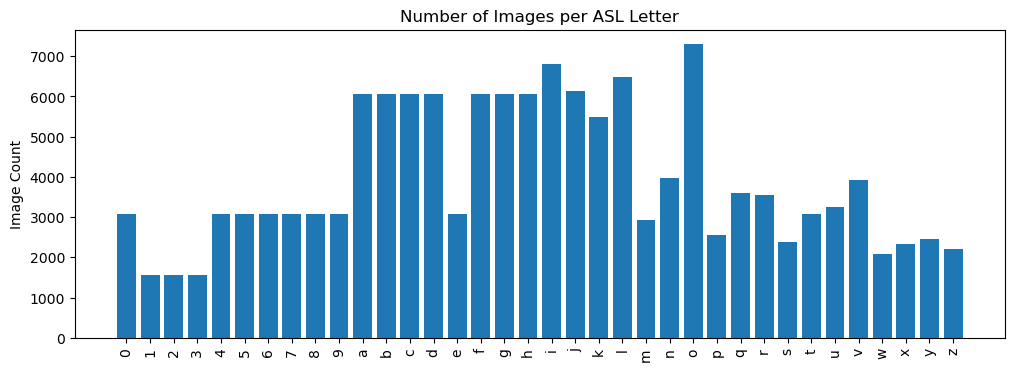

In [58]:
#Plotting class distribution for each ASL letter
plt.figure(figsize=(12,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of Images per ASL Letter")
plt.ylabel("Image Count")
plt.show()

In [59]:
#Function to display sample images for a given ASL letter
def show_samples(letter, n=5):
    folder = os.path.join(DATASET_DIR, letter)
    images = os.listdir(folder)[:n]

    plt.figure(figsize=(6,2))
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).convert("L")
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Sample images for letter '{letter}'")
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()



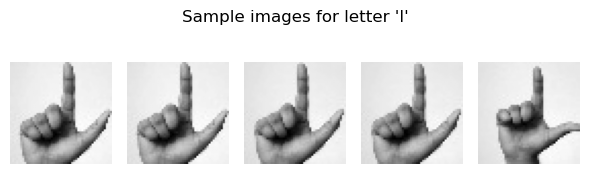

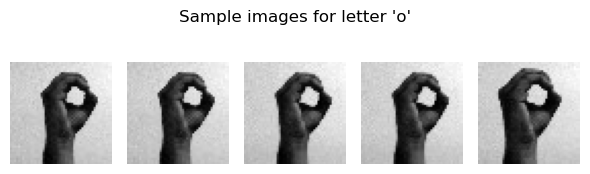

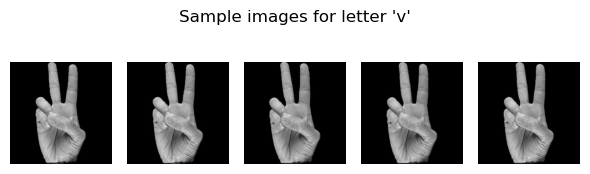

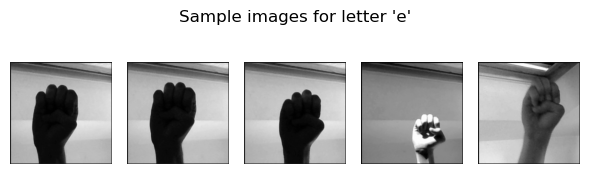

In [77]:
#APPLYING THE FUNCTION TO SOME LETTERS
show_samples("l")
show_samples("o")
show_samples("v")
show_samples("e")

In [61]:
#Creating a summary table of class distributions
counts = pd.Series(class_counts)

letters = counts[counts.index.str.isalpha()]
digits = counts[counts.index.str.isdigit()]

summary_df = pd.DataFrame({
    "Category": ["Letters", "Digits"],
    "Total Images": [letters.sum(), digits.sum()],
    "Average per Class": [letters.mean(), digits.mean()],
    "Min per Class": [letters.min(), digits.min()],
    "Max per Class": [letters.max(), digits.max()]})

summary_df

,Category,Total Images,Average per Class,Min per Class,Max per Class
0,Letters,116061,4463.884615,2086,7294
1,Digits,26200,2620.000000,1570,3070


*What we understand:* Digits have far fewer samples per class than letters.
This means the model is structurally disadvantaged when predicting digits.

In [62]:
#Dataset Composition Analysis
total_images = counts.sum()

composition = pd.DataFrame({
    "Category": ["Letters", "Digits"],
    "Images": [letters.sum(), digits.sum()]
})
composition["Percentage"] = (composition["Images"] / total_images) * 100

composition

,Category,Images,Percentage
0,Letters,116061,81.583146
1,Digits,26200,18.416854


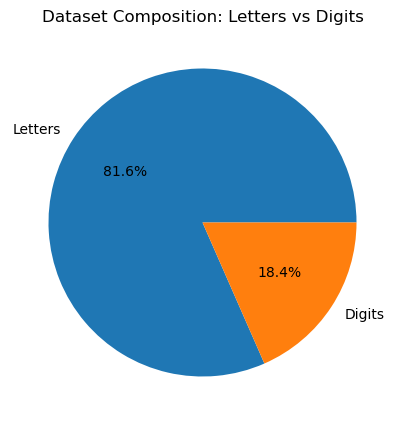

In [63]:
#Visualizing dataset composition
composition.set_index("Category")["Images"].plot(
    kind="pie", autopct="%.1f%%", figsize=(5,5),
    title="Dataset Composition: Letters vs Digits")
plt.ylabel("")
plt.show()


*What we understand:* The dataset composition is skewed toward alphabetic characters, suggesting that numeric gesture recognition may underperform unless explicitly accounted for. This imbalance introduces structural risk that must be monitored at a class-category level.

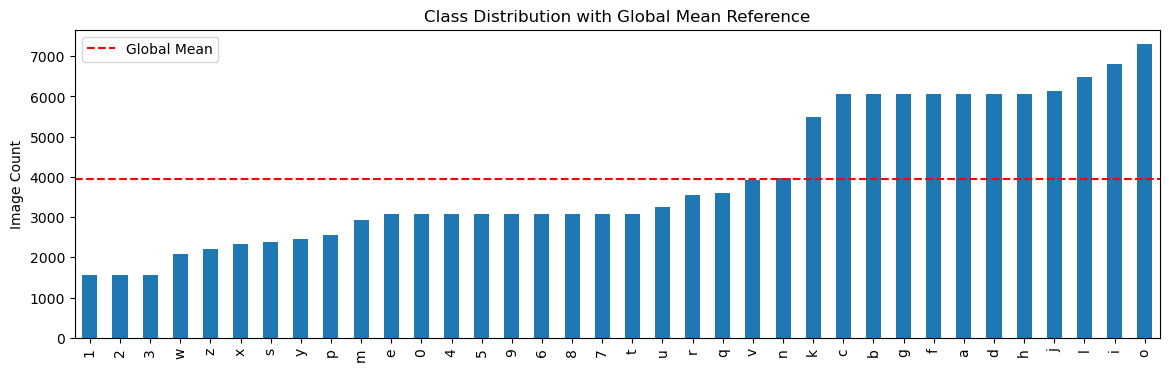

In [64]:
#Visualizing class distribution with global mean reference
plt.figure(figsize=(14,4))
counts.sort_values().plot(kind="bar")
plt.axhline(counts.mean(), color="red", linestyle="--", label="Global Mean")
plt.legend()
plt.title("Class Distribution with Global Mean Reference")
plt.ylabel("Image Count")
plt.show()

*What we understand:* The presence of extreme variance across class frequencies indicates that the dataset is not uniformly representative. Classes below the global mean are at increased risk of misclassification, highlighting the need for class-aware evaluation rather than relying solely on overall accuracy.

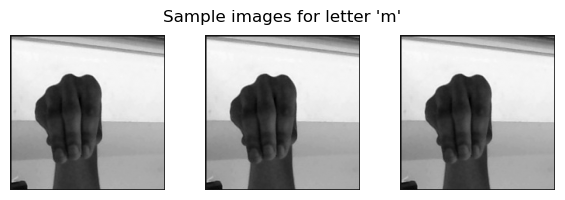

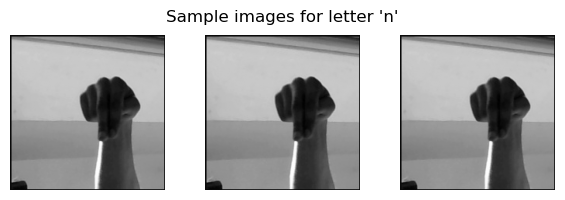

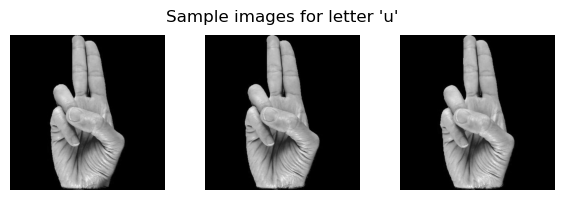

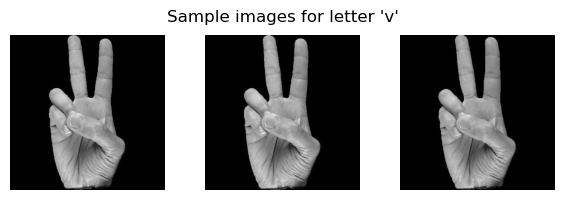

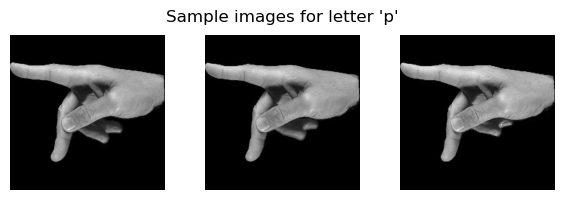

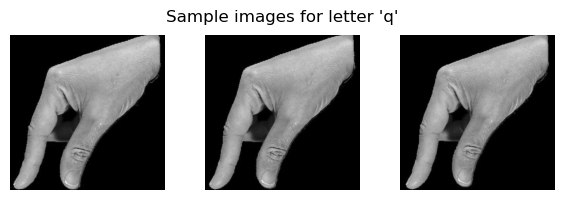

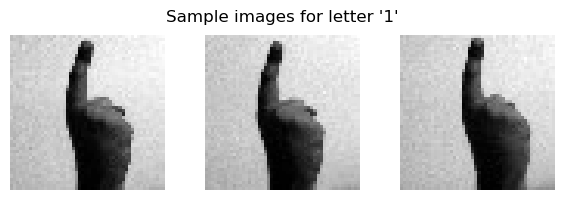

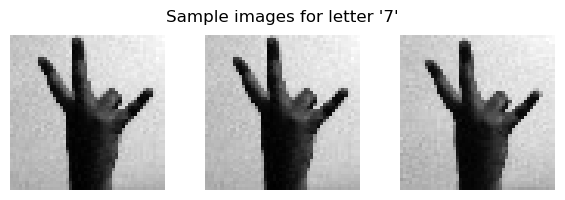

In [65]:
#Displaying sample images for specific confusing pairs
pairs = [("m", "n"), ("u", "v"), ("p", "q"), ("1", "7")]

for a, b in pairs:
    show_samples(a, n=3)
    show_samples(b, n=3)


*What we understand:* Visual inspection revealed that several ASL characters exhibit strong visual similarity, particularly when captured at limited resolution. This similarity is expected to contribute to misclassification and will be examined further using confusion matrices in subsequent phases.

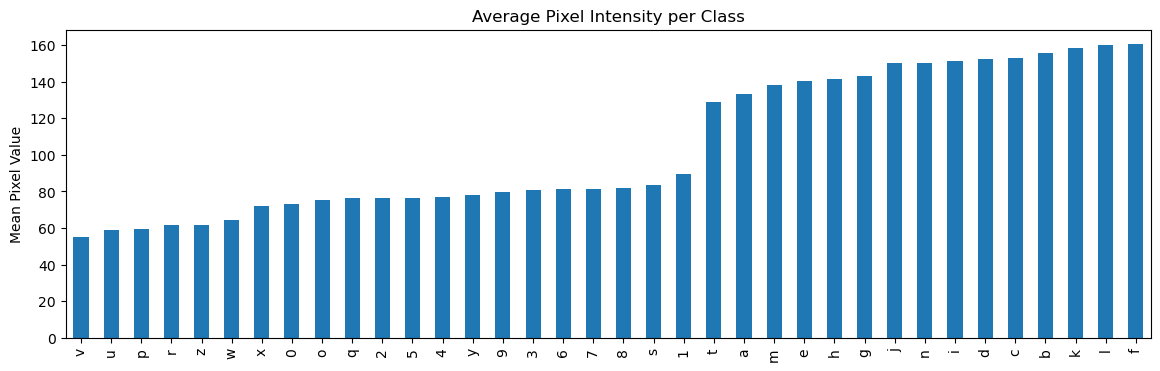

In [66]:
#Analyzing average pixel intensity per class
def pixel_stats(letter):
    folder = os.path.join(DATASET_DIR, letter)
    values = []
    for img_name in os.listdir(folder)[:100]:
        img = Image.open(os.path.join(folder, img_name)).convert("L")
        values.append(np.mean(np.array(img)))
    return np.mean(values)

pixel_means = {k: pixel_stats(k) for k in counts.index}

plt.figure(figsize=(14,4))
pd.Series(pixel_means).sort_values().plot(kind="bar")
plt.title("Average Pixel Intensity per Class")
plt.ylabel("Mean Pixel Value")
plt.show()

*What we understand:* Differences in average pixel intensity across classes suggest inconsistent lighting conditions within the dataset. Such variations may influence model confidence and necessitate normalization and augmentation strategies.

In [67]:
#Calculating dataset entropy to assess class distribution uniformity
probabilities = counts / counts.sum()
dataset_entropy = entropy(probabilities, base=2)

dataset_entropy

np.float64(5.036018702153851)

In [68]:
#Comparing actual entropy to maximum possible entropy
max_entropy = np.log2(len(counts))
print("Actual entropy:", dataset_entropy)
print("Max possible entropy:", max_entropy)
print("Entropy ratio (actual/max):", dataset_entropy / max_entropy)

Actual entropy: 5.036018702153851
Max possible entropy: 5.169925001442312
Entropy ratio (actual/max): 0.974098986106935


*What we understand:* Entropy analysis indicates that the dataset maintains high overall informational diversity, achieving approximately 97% of the maximum possible entropy. While individual classes are unevenly represented, the dataset as a whole is not dominated by a small subset of classes. This suggests that performance issues are likely to arise at the class level rather than from global data scarcity.

In [69]:
#Identifying rare and dominant classes based on quartiles
q25 = counts.quantile(0.25)
q75 = counts.quantile(0.75)

rare_classes = counts[counts < q25]
dominant_classes = counts[counts > q75]


In [70]:
rare_classes

1    1570
2    1570
3    1570
p    2566
s    2374
w    2086
x    2330
y    2454
z    2218
dtype: int64

In [71]:
dominant_classes

i    6807
j    6124
l    6494
o    7294
dtype: int64

*What we understand:*  Quartile-based analysis highlights a subset of ASL characters that are significantly underrepresented. These classes represent high-risk candidates for misclassification and warrant focused evaluation during model validation.

In [72]:
#Analyzing image dimensions across the dataset
sizes = []
for label in os.listdir(DATASET_DIR):
    folder = os.path.join(DATASET_DIR, label)
    for img_name in os.listdir(folder)[:20]:
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

Counter(sizes)

Counter({(50, 50): 440, (400, 400): 200, (200, 200): 80})

*What we understand:* Image dimension analysis identified inconsistencies in resolution across the dataset, with samples ranging from 50×50 to 400×400 pixels. Without standardization, these inconsistencies would introduce variability unrelated to the gesture itself. This finding justifies the need for image resizing and normalization as part of the preprocessing pipeline.

In [73]:
def intra_class_variance(letter):
    folder = os.path.join(DATASET_DIR, letter)
    imgs = []
    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder, img_name)).convert("L")
        imgs.append(np.array(img).flatten())
    return np.var(np.vstack(imgs))

variance_scores = {k: intra_class_variance(k) for k in counts.index}
pd.Series(variance_scores).sort_values(ascending=False).head(10)

s    4524.286594
y    4402.457342
q    4054.842337
x    3812.746892
e    3703.571114
m    3666.886912
w    3574.018491
v    3494.139219
u    3421.819415
z    3271.880684
dtype: float64

*What we understand:* Intra-class variance analysis revealed that several ASL characters exhibit high internal visual variability, independent of sample size. Characters such as S, Y, and Q demonstrate significant variation in hand orientation and shape, increasing classification complexity. This indicates that misclassification risk is influenced not only by class frequency but also by visual diversity within each class.

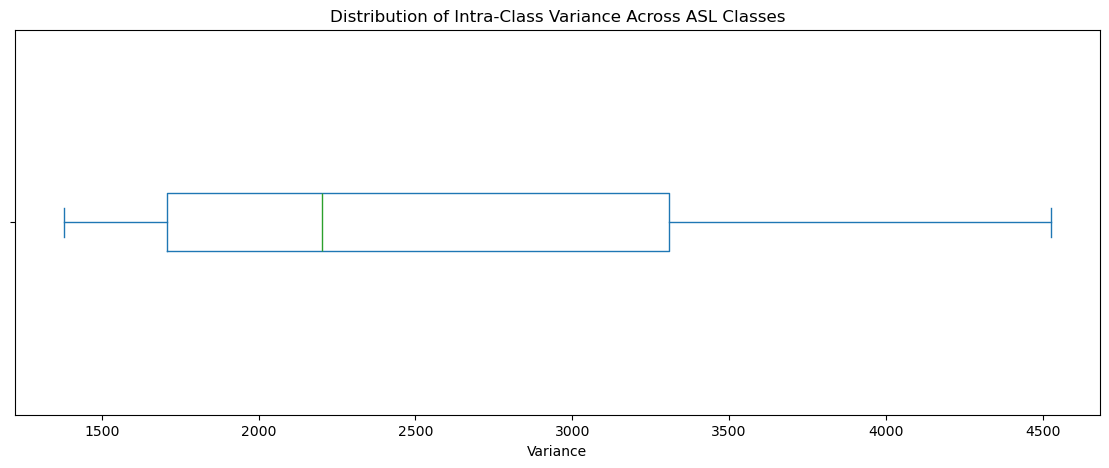

In [54]:
variance_series = pd.Series(variance_scores)

plt.figure(figsize=(14,5))
variance_series.sort_values().plot(kind="box", vert=False)
plt.title("Distribution of Intra-Class Variance Across ASL Classes")
plt.xlabel("Variance")
plt.show()

*What we understand:* Visualization of intra-class variance revealed a highly skewed distribution, with a small number of ASL characters exhibiting extreme internal variability. While most classes demonstrate moderate variance, the long upper tail indicates the presence of structurally complex gestures that disproportionately contribute to classification risk.

In [76]:
risk_index = (
    (counts.max() - counts) / counts.max()) * (
    variance_series / variance_series.max())

risk_index.sort_values(ascending=False).head(10)


s    0.674527
y    0.645691
x    0.573527
w    0.564043
z    0.503273
m    0.485583
e    0.474055
q    0.455123
u    0.419949
p    0.411208
dtype: float64

*What we understand:* A composite risk index combining class imbalance and intra-class variance identified a subset of ASL characters with disproportionately high failure risk. Notably, characters such as S, Y, and X exhibit elevated risk scores due to high internal visual variability, despite moderate or high sample counts. This indicates that classification difficulty is driven by structural visual complexity rather than data scarcity alone.